# 1. Simulation

In [4]:
import sys
sys.path.insert(0, "C:/Users/woong/Desktop/COMP_SCI/Reinforement Learning/Cat and Mouse/Central Q Learning")

import numpy as np
import pandas as pd
import gymnasium as gym
import cam_env_cat_entry
import cam_env_5050_entry

STATES = {(1,3):0,
          (1,4):1,
          (1,5):2,
          (2,3):3,
          (2,4):4,
          (2,5):5,
          (3,3):6,
          (3,4):7,
          (3,5):8}

def get_state_number(observation):
    state_num = STATES[observation]
    
    return state_num


## 1.1 Simulation (Cat Entry)

In [ ]:
q_table = pd.read_csv("cat_entry.csv")
q_table = q_table.drop(q_table.columns[[0]], axis=1).to_numpy()


env = gym.make("CatAndMouse-cat_entry", render_mode = "human")

terminated = False
truncated = False

observation, info = env.reset()

while(not terminated and not truncated):
    state_num = get_state_number(observation)
    
    action = np.argmax(q_table[state_num])
    
    joint_action = (action//2, action%2)
    
    observation, _, terminated, truncated, info = env.step(joint_action)


## 1.2 Simulation (50-50 Entry)

In [ ]:
q_table = pd.read_csv("5050_entry_wo_door.csv")
q_table = q_table.drop(q_table.columns[[0]], axis=1).to_numpy()

env = gym.make("CatAndMouse-5050_entry", render_mode = "human")

terminated = False
truncated = False

observation, info = env.reset()

while(not terminated and not truncated):
    state_num = get_state_number(observation)
    
    action = np.argmax(q_table[state_num])
    
    joint_action = (action//2, action%2)
    
    observation, _, terminated, truncated, info = env.step(joint_action)


# 2. Performance Plotting

In [2]:
def get_joint_action(q_table, state, epsilon):
    if np.random.rand() < epsilon:
        action = np.random.choice(4)
    else:
        action = np.argmax(q_table[state])
    return action

def central_q_learning(env, epochs = 10000, epsilon = 0.1, gamma = 0.9, alpha = 0.9):

    q_table = np.zeros(shape=(36,4))

    for episode in range(epochs):
        if (episode%100==0):
            print(str(100*episode/epochs)+"%","done" , end="\r")

        terminated = False
        truncated = False
        
        observation, info = env.reset()
        
        new_state = get_state_number(observation)
        
        while (not terminated and not truncated):
        
            action = get_joint_action(q_table, new_state , epsilon)
            
            joint_action = (action//2, action%2)
            
            old_state = new_state
            
            observation, reward, terminated, truncated, info = env.step(joint_action)
            
            new_state = get_state_number(observation)
            
            q_table[old_state, action] = q_table[old_state, action] + alpha*(reward + gamma*np.max(q_table[new_state]) - q_table[old_state, action])
    
    return q_table

In [5]:
env = gym.make("CatAndMouse-5050_entry")

return_data = []

for i in range(1, 51):
    print("Current Epochs : ", str(100*i), "/50000")
    
    return_values=[]
    
    for j in range(10):
        q_table = central_q_learning(env, epochs = 100*i, epsilon = 0.1, gamma = 0.9, alpha = 0.01)
    
        terminated = False
        truncated = False
        
        observation, _ = env.reset()

        return_value = 0
        t=1
        while(not terminated and not truncated):
            state_num = get_state_number(observation)
            
            action = np.argmax(q_table[state_num])
            
            joint_action = (action//2, action%2)
            
            observation, reward, terminated, truncated, _ = env.step(joint_action)

            return_value += reward*(0.9**t)
            t+=1
        
        return_values.append(return_value)

    print(str(i),": ", return_values)
    return_data.append(np.mean(return_values))

return_data = pd.DataFrame(return_data)
return_data.to_csv("return_values.csv")


Current Epochs :  100 /50000
1 :  [18.079766263363624, 18.079766263363624, 15.342413153662445, 0.0, 18.079766263363624, 18.079766263363624, 15.342413153662445, 18.079766263363624, 15.342413153662445, 15.342413153662445]
Current Epochs :  200 /50000


c:\Users\woong\AppData\Local\Programs\Python\Python312\Lib\site-packages\gymnasium\utils\passive_env_checker.py:131: UserWarning: WARN: The obs returned by the `reset()` method was expecting a numpy array, actual type: <class 'tuple'>
  logger.warn(
c:\Users\woong\AppData\Local\Programs\Python\Python312\Lib\site-packages\gymnasium\spaces\box.py:240: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")
c:\Users\woong\AppData\Local\Programs\Python\Python312\Lib\site-packages\gymnasium\utils\passive_env_checker.py:131: UserWarning: WARN: The obs returned by the `step()` method was expecting a numpy array, actual type: <class 'tuple'>
  logger.warn(


2 :  [15.342413153662445, 18.079766263363624, 18.079766263363624, 18.079766263363624, 18.079766263363624, 18.079766263363624, 18.079766263363624, 18.079766263363624, 18.079766263363624, 18.079766263363624]
Current Epochs :  300 /50000
3 :  [15.342413153662445, 18.079766263363624, 18.079766263363624, 15.342413153662445, 18.079766263363624, 18.079766263363624, 18.079766263363624, 18.079766263363624, 18.079766263363624, 15.342413153662445]
Current Epochs :  400 /50000
4 :  [18.079766263363624, 15.342413153662445, 0.0, 15.342413153662445, 18.079766263363624, 15.342413153662445, 13.8081718382962, 15.342413153662445, 18.079766263363624, 18.079766263363624]
Current Epochs :  500 /50000
5 :  [18.079766263363624, 18.079766263363624, 13.8081718382962, 18.079766263363624, 18.079766263363624, 15.342413153662445, 15.342413153662445, 18.079766263363624, 18.079766263363624, 15.342413153662445]
Current Epochs :  600 /50000
6 :  [13.8081718382962, 18.079766263363624, 18.079766263363624, 18.079766263363

In [6]:
import matplotlib.pyplot as plt
return_data = pd.read_csv("return_values.csv")
return_data = return_data.drop(return_data.columns[[0]], axis=1)
return_data.insert(0, "Epochs", [100*i for i in range(1, 51)])
return_data.columns = ["Epochs", "Return"]
return_data

,Epochs,Return
0,100,15.176848
1,200,17.806031
2,300,17.258560
3,400,14.749689
4,500,16.831401
5,600,16.831401
6,700,16.984825
7,800,16.557666
8,900,16.557666
9,1000,15.977082


Text(0.5, 1.0, 'Average Expected Return over Epochs')

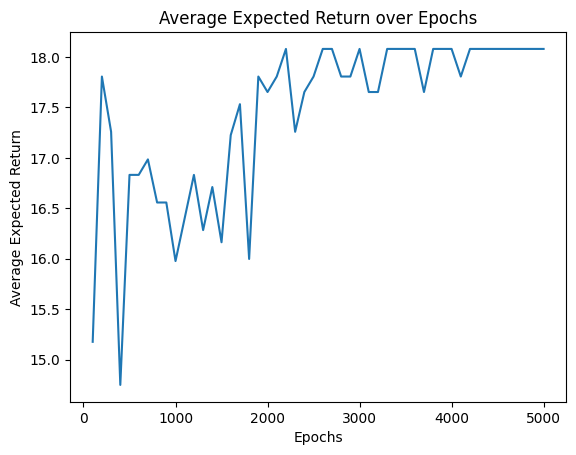

In [8]:
plt.plot(return_data["Epochs"], return_data["Return"])
plt.xlabel("Epochs")
plt.ylabel("Average Expected Return")
plt.title("Average Expected Return over Epochs")